**Import libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import scipy
from scipy import stats
import seaborn as sns
from functools import reduce
import pathlib
from csv import reader
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

/opt/miniconda3/envs/uniprot_notebook/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


**Get input folder path**

Files were processed with following filters:
- removed non tryptic peptides
- removed peptides which had more than 1 missed cleavage site
- proteins need to have at least 2 unique peptides

values represent averaged protein raw signal intensities

In [2]:
#provide folder path
input_folder_path = "/Users/nropek/Dropbox (Dropbox @RU)/TurboID manuscript/Mass-spectrometry datasets/TurboID_analysis/analysis_results/turbo_id_2pepperprot/01_processed_files/"
#turn path into object 
input_path_obj = pathlib.Path(input_folder_path)
#get absolute path
input_path_obj = input_path_obj.resolve()
input_path_obj

PosixPath('/Users/nropek/Dropbox (Dropbox @RU)/TurboID manuscript/Mass-spectrometry datasets/TurboID_analysis/analysis_results/turbo_id_2pepperprot/01_processed_files')

**Get list of files in input folder**

In [3]:
list_of_file_paths = list(input_path_obj.iterdir())
list_of_file_paths
list_of_file_paths = [x for x in list_of_file_paths if 'census-out' in x.stem]

list_of_file_names = []
for file_path in list_of_file_paths:
    file_name = file_path.stem
    list_of_file_names.append(file_name)
list_of_file_names

['processed_census-out_07302022_EV1-100A_10pl_M',
 'processed_census-out_08072022_EV101_16pl_M',
 'processed_census-out_07232022_EV1-100B_10pl_M',
 'processed_census-out_08032022_EV1-100D_10pl_M',
 'processed_census-out_07252022_EV1-100C_10pl_M',
 'processed_census-out_07142022_EV1-98_16pl_M']

**Get metadata**

In [4]:
meta_data_list = []
with open(input_path_obj / "metadata_col.csv", 'r') as read_obj:
    csv_reader = reader(read_obj)
    for row in csv_reader:
        meta_data_list.append(row)

In [5]:
file_channel_dict = {}
for file_name in list_of_file_names:
    channel_dict = {}
    for meta_data_item in meta_data_list[1:]:
        if file_name in meta_data_item:
            channel_dict[meta_data_item[1]] = meta_data_item[2]
    file_channel_dict[file_name] = channel_dict

In [6]:
dfs = []
for file in list_of_file_paths:
    file_dict = {}
    file_name = file.stem
    df = pd.read_csv(file)
    df = df.set_index(["uniprot", 'description', 'pep_num'])
    df.rename(columns=file_channel_dict[file_name], inplace=True)
    file_dict[file_name] = df
    dfs.append(file_dict)

**Additional file information**

- processed_census-out_07302022_EV1-100A_10pl_M_conditions = HF, chow  
- processed_census-out_07302022_EV1-100A_10pl_M_groups = (-), (+)

**Porcessing: EV1-100A_10pl**

In [7]:
#for file_name in list_of_file_names
for subdict in dfs: 
    if "processed_census-out_07302022_EV1-100A_10pl_M" in subdict: 
        df = subdict["processed_census-out_07302022_EV1-100A_10pl_M"]

In [8]:
df.head()

,,,iWAT_HF_cre-_1,iWAT_HF_cre-_2,iWAT_chow_cre-_1,iWAT_chow_cre-_2,iWAT_HF_cre+_1,iWAT_HF_cre+_2,iWAT_HF_cre+_3,iWAT_chow_cre+_1,iWAT_chow_cre+_2,iWAT_chow_cre+_3
uniprot,description,pep_num,,,,,,,,,,
Q9Z0F7,Sncg Gamma-synuclein,10,3483.0,2865.5,2310.5,1617.0,23808.5,12014.5,28521.0,6982.5,13105.5,3358.5
P20152,Vim Vimentin,36,5710.0,6388.0,4460.5,3810.0,9778.0,11874.0,18307.0,7744.0,13584.0,7085.0
A8DUK4,Hbbt1 Protein Hbb-bs,8,2776.0,1925.0,6479.0,6293.5,7394.5,4706.5,8890.0,11554.5,11759.0,6372.5
E9QPD7,Pcx Pyruvate carboxylase,66,10465.0,8326.0,9912.0,4796.0,11582.0,9834.0,10000.0,6014.0,8387.0,6223.0
Q3ULD5,"Mccc2 Methylcrotonoyl-CoA carboxylase beta chain, mitochondrial",29,8484.5,10385.0,14965.5,8374.0,5171.5,5651.5,4870.5,9031.0,11291.5,6537.0


In [9]:
df.shape

(1953, 10)

**Filter and get ratio**

Filtering is performed per condition:
(- the sum of + channels should pass 15000)
(- if not the sum of 2 should be at least 10000+)

we do:
- at least 2 channels out of the 3 cre+ channels should have 5000 singal intensity each

In [10]:
conditions_list = ["HF", "chow"]
control_cols_contain = "cre-"
condition_cols_contain = "cre+"

In [11]:
def get_condition_df(df, condition_name):
    sub_df = df.filter(regex=condition_name)
    return(sub_df)

def filter_condition_df(sub_df, condition_cols_contain, control_cols_contain):
    cond_columns = sub_df.filter(like=condition_cols_contain).columns.tolist()
    ctrl_columns = sub_df.filter(like=control_cols_contain).columns.tolist()

    #sub_df["cond_cols_mean"] = sub_df[cond_columns].mean(axis=1)
    #sub_df["ctrl_cols_mean"] = sub_df[ctrl_columns].mean(axis=1)
    sub_df["count_vals_gt_5000"] = (sub_df[cond_columns] >= 5000).sum(axis=1)

    #sub_df = sub_df[sub_df["cond_cols_mean"].gt(5000)]
    #sub_df = sub_df[sub_df["ctrl_cols_mean"].gt(1000)]
    sub_df = sub_df[sub_df["count_vals_gt_5000"] >= 2]
    return(sub_df, cond_columns, ctrl_columns)

def get_ratio_condition_df(sub_df, cond_columns, ctrl_columns):
    for condition in cond_columns:
        for control in ctrl_columns:
            sub_df["ratio_"+condition+"/"+control] = sub_df[condition] / sub_df[control]
        
    ratio_df = sub_df.filter(regex='ratio_')
    return(ratio_df)

In [12]:
ratio_dfs_dict = {}

for condition in conditions_list:
    print(condition)
    sub_df = get_condition_df(df, condition)
    print("Proteins in this condition:", sub_df.shape)
    #print(sub_df.columns)
    filtered_sub_df, cond_columns, ctrl_columns = filter_condition_df(sub_df, condition_cols_contain, control_cols_contain)
    print("Proteins after filtering:", filtered_sub_df.shape)
    #print(filtered_sub_df.columns)
    filtered_ratio_df = get_ratio_condition_df(filtered_sub_df, cond_columns, ctrl_columns)
    #print(filtered_ratio_df.columns)
    ratio_dfs_dict[condition] = filtered_ratio_df

HF
Proteins in this condition: (1953, 5)
Proteins after filtering: (1691, 6)
chow
Proteins in this condition: (1953, 5)
Proteins after filtering: (1546, 6)


In [13]:
ratio_dfs_dict["HF"].head()

,,,ratio_iWAT_HF_cre+_1/iWAT_HF_cre-_1,ratio_iWAT_HF_cre+_1/iWAT_HF_cre-_2,ratio_iWAT_HF_cre+_2/iWAT_HF_cre-_1,ratio_iWAT_HF_cre+_2/iWAT_HF_cre-_2,ratio_iWAT_HF_cre+_3/iWAT_HF_cre-_1,ratio_iWAT_HF_cre+_3/iWAT_HF_cre-_2
uniprot,description,pep_num,,,,,,
Q9Z0F7,Sncg Gamma-synuclein,10,6.835630,8.308672,3.449469,4.192811,8.188630,9.953237
P20152,Vim Vimentin,36,1.712434,1.530683,2.079510,1.858798,3.206130,2.865842
A8DUK4,Hbbt1 Protein Hbb-bs,8,2.663725,3.841299,1.695425,2.444935,3.202450,4.618182
E9QPD7,Pcx Pyruvate carboxylase,66,1.106737,1.391064,0.939704,1.181119,0.955566,1.201057
Q3ULD5,"Mccc2 Methylcrotonoyl-CoA carboxylase beta chain, mitochondrial",29,0.609523,0.497978,0.666097,0.544198,0.574047,0.468994


In [14]:
ratio_dfs_dict["chow"].head()

,,,ratio_iWAT_chow_cre+_1/iWAT_chow_cre-_1,ratio_iWAT_chow_cre+_1/iWAT_chow_cre-_2,ratio_iWAT_chow_cre+_2/iWAT_chow_cre-_1,ratio_iWAT_chow_cre+_2/iWAT_chow_cre-_2,ratio_iWAT_chow_cre+_3/iWAT_chow_cre-_1,ratio_iWAT_chow_cre+_3/iWAT_chow_cre-_2
uniprot,description,pep_num,,,,,,
Q9Z0F7,Sncg Gamma-synuclein,10,3.022073,4.318182,5.672149,8.104824,1.453581,2.076994
P20152,Vim Vimentin,36,1.736128,2.032546,3.045398,3.565354,1.588387,1.859580
A8DUK4,Hbbt1 Protein Hbb-bs,8,1.783377,1.835942,1.814941,1.868436,0.983562,1.012553
E9QPD7,Pcx Pyruvate carboxylase,66,0.606739,1.253962,0.846146,1.748749,0.627825,1.297540
Q3ULD5,"Mccc2 Methylcrotonoyl-CoA carboxylase beta chain, mitochondrial",29,0.603455,1.078457,0.754502,1.348400,0.436805,0.780631


In [15]:
ratio_dfs_dict["HF"].shape

(1691, 6)

In [16]:
ratio_dfs_dict["chow"].shape

(1546, 6)

**Annotate each condition table with TP and FP lists**

- if uniprot id is in TP list the annotation column will be filled with "TP" 
- if uniprot id is in FP list the annotation column will be filled with "FP" 
- if uniprot id is in any of them annotation column will be filled with "None"

In [17]:
#get lists
FP_df = pd.read_csv("/Users/nropek/Dropbox (Dropbox @RU)/TurboID manuscript/Mass-spectrometry datasets/TurboID_analysis/mouse_lists/mouse_FP_list_cyt_nuc_TFs.csv")
FP_list = FP_df["Entry"].tolist()
print("Number of Uniport IDs in FP list:", len(FP_list))
TP_df = pd.read_csv("/Users/nropek/Dropbox (Dropbox @RU)/TurboID manuscript/Mass-spectrometry datasets/TurboID_analysis/mouse_lists/mouse_TP_list_secreted.csv")
TP_list = TP_df["Entry"].tolist()
print("Number of Uniport IDs in TP list:", len(TP_list))

Number of Uniport IDs in FP list: 7971
Number of Uniport IDs in TP list: 8981


In [18]:
def annotate_uniprot(uniprot_id):
    if uniprot_id in TP_list:
        return "TP"
    elif uniprot_id in FP_list:
        return "FP"

In [19]:
for condition, table in ratio_dfs_dict.items(): 
    print(condition)
    print(table.shape)
    table = table.reset_index()
    uniprot_ids = table["uniprot"]
    table["annotation"] = table["uniprot"].apply(annotate_uniprot)
    table = table.set_index(["uniprot", 'description', 'pep_num', 'annotation'])
    ratio_dfs_dict[condition] = table    


HF
(1691, 6)
chow
(1546, 6)


**Merge ratio dfs with raw signal intensity table**

In [20]:
ratio_tables = list(ratio_dfs_dict.values())
ratio_tables = [table.reset_index() for table in ratio_tables]

In [21]:
col_list = ['uniprot', 'description', 'pep_num', 'annotation']
ratio_tables_merged = reduce(lambda df1,df2: pd.merge(df1,df2,on=col_list, how="outer"), ratio_tables)
ratio_tables_merged.shape

(1776, 16)

In [22]:
ratio_and_signal_intensity = ratio_tables_merged.merge(df, on=['uniprot', 'description', 'pep_num'], how='outer')

**For the next steps we followed methods section "Data analysis" of https://www.nature.com/articles/s41596-020-0399-0**

- Analyze each replicate seperately

- Normalize corresponding TMT ratios against the distribution of FP proteins that should not be biotinylated by TurboID (FP list). To do this, divide all TMT ratios by the median of the ratios for FP proteins.

- Calculate the log2 value of each ratio; log2 values will be used for the rest of the analysis. This normalization centers the distribution of the log2 ratios of nonspecifically binding proteins around 0.

- Check the correlation between replicates by plotting the corresponding log2 ratios.

- Rank the proteins by the appropriate TMT ratio values in descending order and cross this list with the TP and FP lists to determine which proteins are TPs and FPs, respectively.

- At each potential cutoff, calculate the TPR and FP rate (FPR), where the TPR/FPR is defined as the number of detected TP/FP proteins detected above the cutoff divided by the total number of detected TP/FP proteins in that replicate. A plot of the TPR versus the FPR should show that the curve bows out as compared with the diagonal, which shows that the proteomic experiment successfully enriched TP proteins over FP proteins (Fig. 4c).

- Determine the cutoff by using the log2 ratio that corresponds to the maximum TPR-FPR value. In cases in which the list of TP proteins is small (e.g., ER–mitochondria contacts; Fig. 5a–d), the cutoff can be alternatively determined with a FDR cutoff (Fig. 5d), where FDR is defined as the fraction of FP proteins detected above each cutoff.

- Retain all proteins with log2 ratios higher than that of the determined cutoff.



Analyzing:  ratio_iWAT_HF_cre+_1/iWAT_HF_cre-_1
Empty DataFrame
Columns: [uniprot, annotation, log2_norm_ratio_iWAT_HF_cre+_1/iWAT_HF_cre-_1]
Index: []
Number of proteins without nans for ratio: 1691
Number of annotated TP:  568
Number of annotated FP:  363


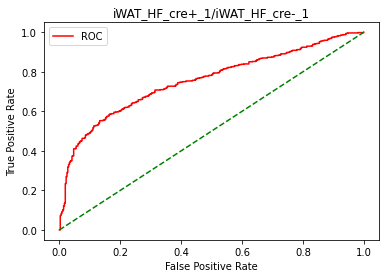

Cutoff value: 0.6627360835608478


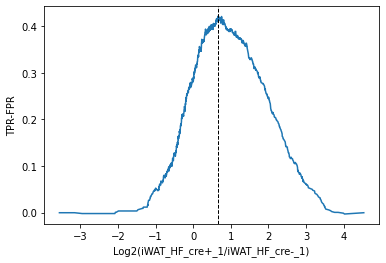

Analyzing:  ratio_iWAT_HF_cre+_1/iWAT_HF_cre-_2
Empty DataFrame
Columns: [uniprot, annotation, log2_norm_ratio_iWAT_HF_cre+_1/iWAT_HF_cre-_2]
Index: []
Number of proteins without nans for ratio: 1691
Number of annotated TP:  568
Number of annotated FP:  363


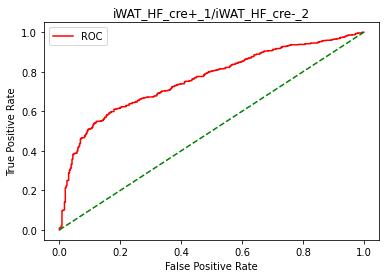

Cutoff value: 0.7462337892566944


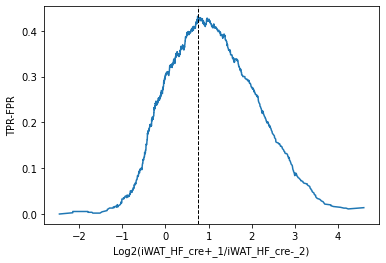

Analyzing:  ratio_iWAT_HF_cre+_2/iWAT_HF_cre-_1
Empty DataFrame
Columns: [uniprot, annotation, log2_norm_ratio_iWAT_HF_cre+_2/iWAT_HF_cre-_1]
Index: []
Number of proteins without nans for ratio: 1691
Number of annotated TP:  568
Number of annotated FP:  363


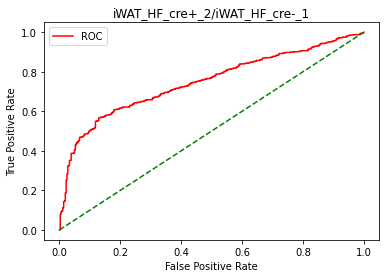

Cutoff value: 0.7609481866525266


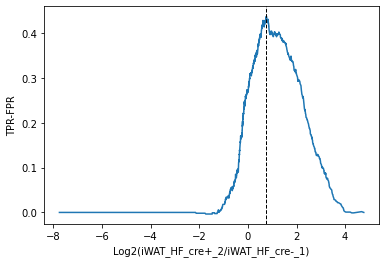

Analyzing:  ratio_iWAT_HF_cre+_2/iWAT_HF_cre-_2
Empty DataFrame
Columns: [uniprot, annotation, log2_norm_ratio_iWAT_HF_cre+_2/iWAT_HF_cre-_2]
Index: []
Number of proteins without nans for ratio: 1691
Number of annotated TP:  568
Number of annotated FP:  363


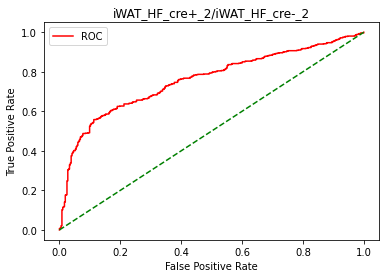

Cutoff value: 0.893935550118744


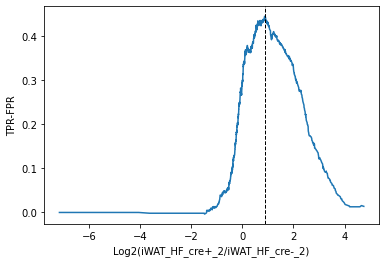

Analyzing:  ratio_iWAT_HF_cre+_3/iWAT_HF_cre-_1
Empty DataFrame
Columns: [uniprot, annotation, log2_norm_ratio_iWAT_HF_cre+_3/iWAT_HF_cre-_1]
Index: []
Number of proteins without nans for ratio: 1691
Number of annotated TP:  568
Number of annotated FP:  363


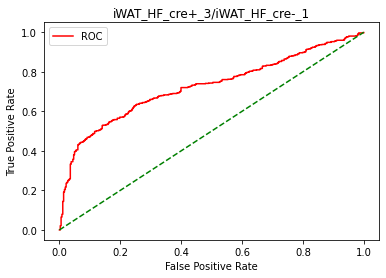

Cutoff value: 0.853837313523496


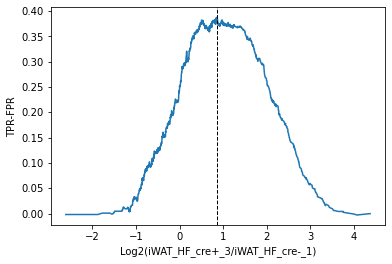

Analyzing:  ratio_iWAT_HF_cre+_3/iWAT_HF_cre-_2
Empty DataFrame
Columns: [uniprot, annotation, log2_norm_ratio_iWAT_HF_cre+_3/iWAT_HF_cre-_2]
Index: []
Number of proteins without nans for ratio: 1691
Number of annotated TP:  568
Number of annotated FP:  363


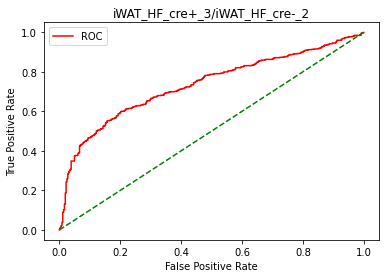

Cutoff value: 0.7795857613972046


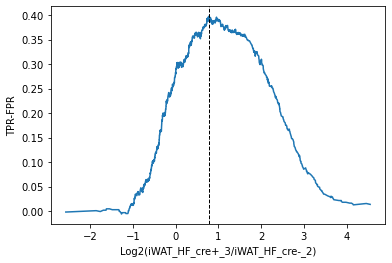

Analyzing:  ratio_iWAT_chow_cre+_1/iWAT_chow_cre-_1
Empty DataFrame
Columns: [uniprot, annotation, log2_norm_ratio_iWAT_chow_cre+_1/iWAT_chow_cre-_1]
Index: []
Number of proteins without nans for ratio: 1546
Number of annotated TP:  529
Number of annotated FP:  353


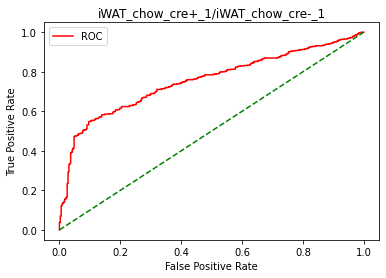

Cutoff value: 1.2415689101958824


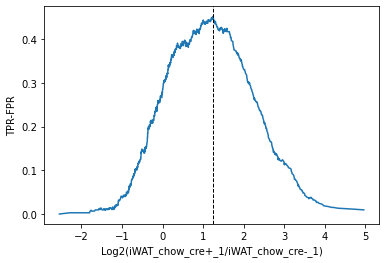

Analyzing:  ratio_iWAT_chow_cre+_1/iWAT_chow_cre-_2
Empty DataFrame
Columns: [uniprot, annotation, log2_norm_ratio_iWAT_chow_cre+_1/iWAT_chow_cre-_2]
Index: []
Number of proteins without nans for ratio: 1546
Number of annotated TP:  529
Number of annotated FP:  353


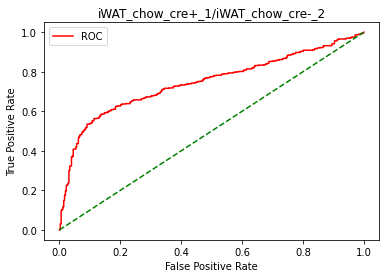

Cutoff value: 1.0264432621873012


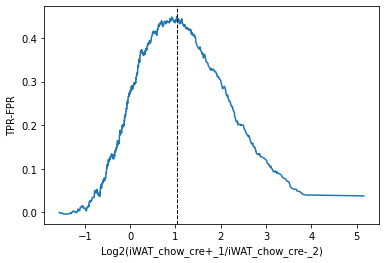

Analyzing:  ratio_iWAT_chow_cre+_2/iWAT_chow_cre-_1
Empty DataFrame
Columns: [uniprot, annotation, log2_norm_ratio_iWAT_chow_cre+_2/iWAT_chow_cre-_1]
Index: []
Number of proteins without nans for ratio: 1546
Number of annotated TP:  529
Number of annotated FP:  353


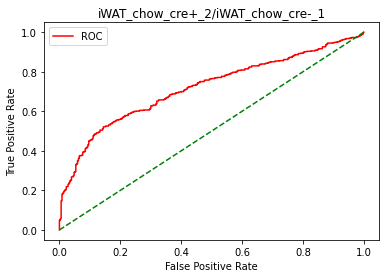

Cutoff value: 1.0520179622317294


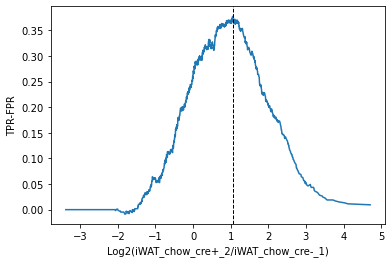

Analyzing:  ratio_iWAT_chow_cre+_2/iWAT_chow_cre-_2
Empty DataFrame
Columns: [uniprot, annotation, log2_norm_ratio_iWAT_chow_cre+_2/iWAT_chow_cre-_2]
Index: []
Number of proteins without nans for ratio: 1546
Number of annotated TP:  529
Number of annotated FP:  353


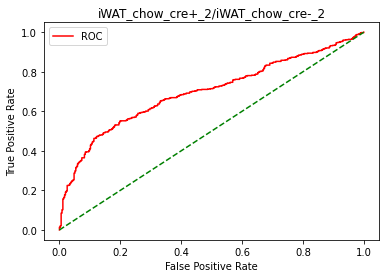

Cutoff value: 0.6495219205308926


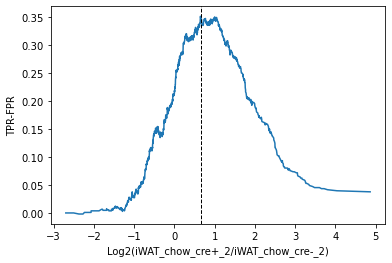

Analyzing:  ratio_iWAT_chow_cre+_3/iWAT_chow_cre-_1
Empty DataFrame
Columns: [uniprot, annotation, log2_norm_ratio_iWAT_chow_cre+_3/iWAT_chow_cre-_1]
Index: []
Number of proteins without nans for ratio: 1546
Number of annotated TP:  529
Number of annotated FP:  353


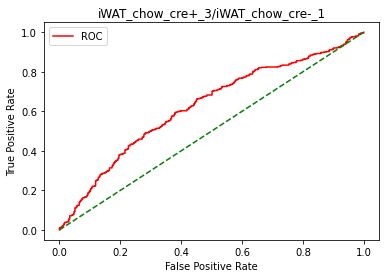

Cutoff value: 0.26951546349579153


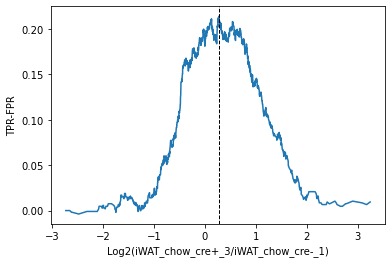

Analyzing:  ratio_iWAT_chow_cre+_3/iWAT_chow_cre-_2
Empty DataFrame
Columns: [uniprot, annotation, log2_norm_ratio_iWAT_chow_cre+_3/iWAT_chow_cre-_2]
Index: []
Number of proteins without nans for ratio: 1546
Number of annotated TP:  529
Number of annotated FP:  353


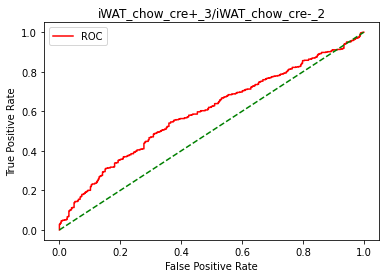

Cutoff value: 0.27778011851329504


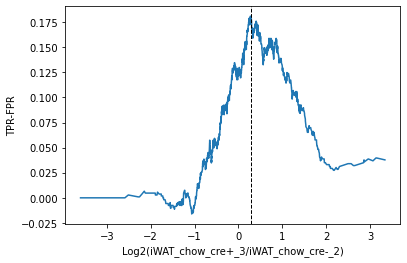

In [23]:
all_cond_full_tables = {}
all_cond_cutoff_tables = {}

for condition, table in ratio_dfs_dict.items():     
    this_condition_full_tables = []
    this_condition_cutoff_tables = []
    
    columns_list = table.columns.tolist()
    table = table.reset_index()
    
    for column in columns_list:
        
        #get replicate
        df_rep = table[["uniprot", "annotation", column]]
        
        print("Analyzing: ", column)
        
        #normalize ratios
        median_FP_ratio = df_rep.loc[df_rep['annotation'] == 'FP', column].median()
        df_rep[column] = df_rep[column].div(median_FP_ratio)
        df_rep[column] = np.log2(df_rep[column]) 
        log2_norm_ratio_column = column.replace("ratio_", "log2_norm_ratio_")
        df_rep.rename(columns={column: log2_norm_ratio_column}, inplace=True)
        column = column.replace("ratio_", "")

        
        print(df_rep[df_rep[log2_norm_ratio_column].isna()])
        df_rep = df_rep[df_rep[log2_norm_ratio_column].notna()]
        
        print("Number of proteins without nans for ratio:", df_rep.shape[0])
        
        #get total number of annotated TP and FP
        total_TP = len(df_rep[df_rep["annotation"] == "TP"])
        total_FP = len(df_rep[df_rep["annotation"] == "FP"])
        print("Number of annotated TP: ", total_TP)
        print("Number of annotated FP: ", total_FP)
        
        #rank ratio in descending order
        df_rep = df_rep.sort_values(log2_norm_ratio_column, ascending=False)
        
        #clean up index
        df_rep = df_rep.reset_index(drop=True)
        #get index as list
        index_list = df_rep.index.values.tolist()
        
        #for each row calculate number of TP and FP in all the rows before
        for row_number in index_list:
            if row_number == 0:
                df_rep.loc[df_rep.index[row_number], 'FP'] = 0
                df_rep.loc[df_rep.index[row_number], 'TP'] = 0
            
            else:
                results_dict = {}
                subset_df = df_rep.loc[0:row_number-1]
                for idx, name in enumerate(subset_df.annotation.value_counts().index.tolist()):
                    results_dict[name] = subset_df.annotation.value_counts()[idx]

                if 'FP' in results_dict:
                    df_rep.loc[df_rep.index[row_number], 'FP'] = results_dict["FP"]
                else:
                    df_rep.loc[df_rep.index[row_number], 'FP'] = 0
                if 'TP' in results_dict:
                    df_rep.loc[df_rep.index[row_number], 'TP'] = results_dict["TP"]
                else:
                    df_rep.loc[df_rep.index[row_number], 'TP'] = 0

        #calculate TPR and FPR
        df_rep["TPR"] = df_rep["TP"] / total_TP
        df_rep["FPR"] = df_rep["FP"] / total_FP
        
        #plot TPR and FPR 
        plt.plot(df_rep["FPR"], df_rep["TPR"], color='red', label='ROC')
        plt.plot([0, 1], [0, 1], color='green', linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(column)
        plt.legend()
        plt.show()
        
        #calculate TPR-FPR, get cutoff value = maximum TPR-FPR value
        df_rep["TPR-FPR"] = df_rep["TPR"] - df_rep["FPR"]
        cutoff_value = df_rep.loc[df_rep["TPR-FPR"].idxmax()][log2_norm_ratio_column]
        print("Cutoff value:", cutoff_value)
    
        #plot log2 ratio and TPR-FPR
        ax = sns.lineplot(df_rep[log2_norm_ratio_column], df_rep["TPR-FPR"])
    
        # Setting the X and Y Label
        xlabel_string = "Log2(" + column + ")"
        ax.set_xlabel(xlabel_string)
        ax.set_ylabel('TPR-FPR')
        ax.axvline(cutoff_value, linewidth=1, color="black", linestyle = "--")
        plt.show()
    
        #Retain all proteins with log2 ratios higher than that of the determined cutoff
        #df_rep_cutoff = df_rep[df_rep[log2_norm_ratio_column] > cutoff_value]
        df_rep["pass_cutoff"] = np.where(df_rep[log2_norm_ratio_column] > cutoff_value, cutoff_value, 0)
        #df_rep_cutoff = df_rep[df_rep["FPR"] < 0.1] FDR 10 %
        
        this_condition_full_table = []
        this_condition_cutoff_table = []
        
        this_condition_full_tables.append(df_rep)
        this_condition_cutoff_tables.append(df_rep)
        
        #print(df_rep[column].min())
        #column = column.replace("/", "-")
        #filename = column +".csv"
        #df_rep.to_csv(filename)
        #rep_protein_dfs_which_pass_cutoff.append(df_rep)
    
    all_cond_full_tables[condition] = this_condition_full_tables
    all_cond_cutoff_tables[condition] = this_condition_cutoff_tables

**For each replicate get number of proteins that pass cutoff**

In [24]:
print("Proteins that pass cutoff:")
print("")

for condition, table_list in all_cond_cutoff_tables.items():
    for table in table_list:
        #col_name = table.columns.tolist()[-6]
        col_name = table.filter(like='log2_norm_ratio_').columns.tolist()
        col_name = col_name[0]
        col_name = col_name.replace("log2_norm_ratio_", "")
        print(col_name)
        print("Number of proteins", table.shape[0])
        #get total number of annotated TP and FP
        total_TP = len(table[table["annotation"] == "TP"])
        total_FP = len(table[table["annotation"] == "FP"])
        print("Number of annotated TP: ", total_TP)
        print("Number of annotated FP: ", total_FP)
        print("")
        table.drop('TP', axis=1, inplace=True)
        table.drop('FP', axis=1, inplace=True)
        table.rename(columns={"pass_cutoff": "pass_cutoff_"+col_name,
                              "TPR": "TPR_"+col_name, 
                              "FPR": "FPR_"+col_name, 
                              "TPR-FPR": "TPR-FPR_"+col_name, 
                              "TPR-FPR": "TPR-FPR_"+col_name}, inplace=True)
        
        

Proteins that pass cutoff:

iWAT_HF_cre+_1/iWAT_HF_cre-_1
Number of proteins 1691
Number of annotated TP:  568
Number of annotated FP:  363

iWAT_HF_cre+_1/iWAT_HF_cre-_2
Number of proteins 1691
Number of annotated TP:  568
Number of annotated FP:  363

iWAT_HF_cre+_2/iWAT_HF_cre-_1
Number of proteins 1691
Number of annotated TP:  568
Number of annotated FP:  363

iWAT_HF_cre+_2/iWAT_HF_cre-_2
Number of proteins 1691
Number of annotated TP:  568
Number of annotated FP:  363

iWAT_HF_cre+_3/iWAT_HF_cre-_1
Number of proteins 1691
Number of annotated TP:  568
Number of annotated FP:  363

iWAT_HF_cre+_3/iWAT_HF_cre-_2
Number of proteins 1691
Number of annotated TP:  568
Number of annotated FP:  363

iWAT_chow_cre+_1/iWAT_chow_cre-_1
Number of proteins 1546
Number of annotated TP:  529
Number of annotated FP:  353

iWAT_chow_cre+_1/iWAT_chow_cre-_2
Number of proteins 1546
Number of annotated TP:  529
Number of annotated FP:  353

iWAT_chow_cre+_2/iWAT_chow_cre-_1
Number of proteins 1546
Nu

**Merge replicates of the same condition into one table and get everything in one table (outer merge)**

In [25]:
output_path = '/Users/nropek/Dropbox (Dropbox @RU)/TurboID manuscript/Mass-spectrometry datasets/TurboID_analysis/notebook_analysis/EV1-100A/2_pep_per_protein'
output_path_obj = pathlib.Path(output_path)
#get absolute path
output_path_obj = output_path_obj.resolve()
output_path_obj

PosixPath('/Users/nropek/Dropbox (Dropbox @RU)/TurboID manuscript/Mass-spectrometry datasets/TurboID_analysis/notebook_analysis/EV1-100A/2_pep_per_protein')

In [26]:
merged_replicate_tables = []
for condition, table_list in all_cond_cutoff_tables.items():
    df = reduce(lambda df1,df2: pd.merge(df1,df2,on=['uniprot', 'annotation'], how="outer"), table_list)
    #df.to_csv(condition+"_cutoff_replicates_merged.csv")
    merged_replicate_tables.append(df)
    print(condition)
    print("Number of proteins for all replicates (inner merge): ", df.shape[0])
    total_TP = len(df[df["annotation"] == "TP"])
    total_FP = len(df[df["annotation"] == "FP"])
    print("Number of annotated TP: ", total_TP)
    print("Number of annotated FP: ", total_FP)

HF
Number of proteins for all replicates (inner merge):  1691
Number of annotated TP:  568
Number of annotated FP:  363
chow
Number of proteins for all replicates (inner merge):  1546
Number of annotated TP:  529
Number of annotated FP:  353


**Merge cutoff ratio from all conditions in one file**

In [27]:
df_all = reduce(lambda df1,df2: pd.merge(df1,df2,on=['uniprot', 'annotation'], how="outer"), merged_replicate_tables)
df_all.shape

(1776, 62)

In [28]:
df_all.head()

,uniprot,annotation,log2_norm_ratio_iWAT_HF_cre+_1/iWAT_HF_cre-_1,TPR_iWAT_HF_cre+_1/iWAT_HF_cre-_1,FPR_iWAT_HF_cre+_1/iWAT_HF_cre-_1,TPR-FPR_iWAT_HF_cre+_1/iWAT_HF_cre-_1,pass_cutoff_iWAT_HF_cre+_1/iWAT_HF_cre-_1,log2_norm_ratio_iWAT_HF_cre+_1/iWAT_HF_cre-_2,TPR_iWAT_HF_cre+_1/iWAT_HF_cre-_2,FPR_iWAT_HF_cre+_1/iWAT_HF_cre-_2,...,log2_norm_ratio_iWAT_chow_cre+_3/iWAT_chow_cre-_1,TPR_iWAT_chow_cre+_3/iWAT_chow_cre-_1,FPR_iWAT_chow_cre+_3/iWAT_chow_cre-_1,TPR-FPR_iWAT_chow_cre+_3/iWAT_chow_cre-_1,pass_cutoff_iWAT_chow_cre+_3/iWAT_chow_cre-_1,log2_norm_ratio_iWAT_chow_cre+_3/iWAT_chow_cre-_2,TPR_iWAT_chow_cre+_3/iWAT_chow_cre-_2,FPR_iWAT_chow_cre+_3/iWAT_chow_cre-_2,TPR-FPR_iWAT_chow_cre+_3/iWAT_chow_cre-_2,pass_cutoff_iWAT_chow_cre+_3/iWAT_chow_cre-_2
0,O89001,NaN,inf,0.000000,0.000000,0.000000,0.662736,0.770938,0.598592,0.173554,...,0.428098,0.521739,0.331445,0.190294,0.269515,inf,0.032136,0.002833,0.029303,0.27778
1,E9Q4X2,NaN,inf,0.000000,0.000000,0.000000,0.662736,1.963987,0.323944,0.038567,...,2.774666,0.013233,0.005666,0.007567,0.269515,2.304460,0.051040,0.019830,0.031210,0.27778
2,Q9Z2G9,FP,4.535028,0.000000,0.000000,0.000000,0.662736,4.595215,0.019366,0.005510,...,0.501954,0.504726,0.303116,0.201610,0.269515,1.090539,0.236295,0.118980,0.117315,0.27778
3,Q6ZQI3,TP,4.022343,0.000000,0.002755,-0.002755,0.662736,4.134915,0.021127,0.008264,...,0.591903,0.461248,0.271955,0.189293,0.269515,0.817430,0.313800,0.167139,0.146661,0.27778
4,Q99LJ6,TP,3.993701,0.001761,0.002755,-0.000994,0.662736,4.057128,0.022887,0.008264,...,1.243301,0.204159,0.101983,0.102176,0.269515,1.224596,0.202268,0.101983,0.100285,0.27778


In [29]:
df_all.to_csv(output_path_obj / ("log2_FPR_TPR_hf_chow_EV1-100A_after_cutoff.csv"), index=False)

**Get ratio and signal intensity for proteins that pass cutoff**

In [30]:
#uniprot_list_passed_cutoff = df_all['uniprot'].tolist()
#len(uniprot_list_passed_cutoff)

In [31]:
#ratio_and_signal_intensity_cutoff = ratio_and_signal_intensity[ratio_and_signal_intensity['uniprot'].isin(uniprot_list_passed_cutoff)]

In [32]:
#ratio_and_signal_intensity_cutoff.shape

In [33]:
ratio_and_signal_intensity.set_index(['uniprot', 'description', 'pep_num', 'annotation'], inplace=True)

In [34]:
ratio_cols_HF = ratio_and_signal_intensity.filter(like="ratio_iWAT_HF").columns.tolist()
ratio_cols_chow = ratio_and_signal_intensity.filter(like="ratio_iWAT_chow").columns.tolist()
ratio_cols_HF

['ratio_iWAT_HF_cre+_1/iWAT_HF_cre-_1',
 'ratio_iWAT_HF_cre+_1/iWAT_HF_cre-_2',
 'ratio_iWAT_HF_cre+_2/iWAT_HF_cre-_1',
 'ratio_iWAT_HF_cre+_2/iWAT_HF_cre-_2',
 'ratio_iWAT_HF_cre+_3/iWAT_HF_cre-_1',
 'ratio_iWAT_HF_cre+_3/iWAT_HF_cre-_2']

In [35]:
column_list = ratio_and_signal_intensity.columns.tolist()
column_list = [colname for colname in column_list if "ratio" not in colname]
hf_raw_int = [colname for colname in column_list if "HF_cre+" in colname]
chow_raw_int = [colname for colname in column_list if "chow_cre+" in colname]
hf_raw_int

['iWAT_HF_cre+_1', 'iWAT_HF_cre+_2', 'iWAT_HF_cre+_3']

In [36]:
ratio_and_signal_intensity["avg_SI(HF)"] = ratio_and_signal_intensity[hf_raw_int].mean(axis=1)
ratio_and_signal_intensity["avg_SI(chow)"] = ratio_and_signal_intensity[chow_raw_int].mean(axis=1)
ratio_and_signal_intensity["avg_SI(HF)/avg_SI(chow)"] = ratio_and_signal_intensity["avg_SI(HF)"].div(ratio_and_signal_intensity["avg_SI(chow)"])

ratio_and_signal_intensity["avg_R(HF)"] = ratio_and_signal_intensity[ratio_cols_HF].mean(axis=1)
ratio_and_signal_intensity["avg_R(chow)"] = ratio_and_signal_intensity[ratio_cols_chow].mean(axis=1)
ratio_and_signal_intensity["avg_R(HF)/avg_R(chow)"] = ratio_and_signal_intensity["avg_R(HF)"].div(ratio_and_signal_intensity["avg_R(chow)"])

In [37]:
ratio_and_signal_intensity.drop("avg_R(HF)", inplace=True, axis=1)
ratio_and_signal_intensity.drop("avg_R(chow)", inplace=True, axis=1)
ratio_and_signal_intensity.drop("avg_SI(HF)", inplace=True, axis=1)
ratio_and_signal_intensity.drop("avg_SI(chow)", inplace=True, axis=1)

In [38]:
ratio_and_signal_intensity = ratio_and_signal_intensity.reset_index()

In [39]:
#merge 
df_all_list_columns_TPRFPR = df_all.filter(like="TPR-FPR").columns.tolist()
df_all_list_columns_passcutoff = df_all.filter(like="pass_cutoff").columns.tolist()

columns_list_df_all = df_all_list_columns_TPRFPR + df_all_list_columns_passcutoff
columns_list_df_all.append("uniprot")

ratio_and_signal_intensity_merged = pd.merge(ratio_and_signal_intensity, df_all[columns_list_df_all],on="uniprot", how="outer")
ratio_and_signal_intensity_merged.shape

(1953, 52)

In [40]:
ratio_and_signal_intensity_merged.to_csv(output_path_obj / ("ratio_raw_values_hf_chow_EV1-100A_after_cutoff.csv"), index=False)